In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Imges.zip to Imges (1).zip


In [ ]:
import zipfile
with zipfile.ZipFile("Imges.zip", "r") as zip_ref:
  zip_ref.extractall("/content")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
rotation_range=30,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,
# vertical_flip=True,
width_shift_range=0.2,
height_shift_range=0.2,
fill_mode='nearest'
)

In [ ]:
data = datagen.flow_from_directory(
"/content/Imges",
target_size=(224, 224),
batch_size=32,
class_mode="categorical"
)

Found 30 images belonging to 3 classes.


In [ ]:
data = datagen.flow_from_directory(
"/content/Imges",
target_size=(224, 224),
batch_size=32,
class_mode="categorical"
)

Found 30 images belonging to 3 classes.


In [ ]:
print(data.class_indices)

{'Jash': 0, 'Mohak': 1, 'Sonu': 2}


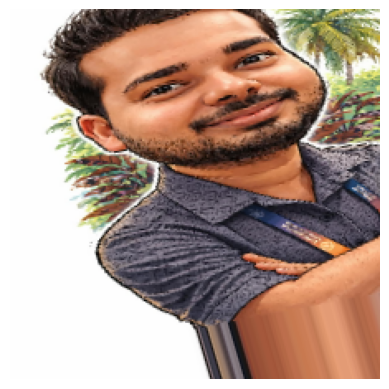

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(data)
plt.imshow(images[7].astype("uint8"))
plt.axis("off")
plt.show()

In [ ]:
import os

path = "/content/Imges"
classes = ["Sonu", "Mohak", "Jash"]

for class_name in classes:
    folder = os.path.join(path, class_name)
    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(class_name, count)


Sonu 10
Mohak 10
Jash 10


In [ ]:
import os
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

original_path = "/content/Imges"
augmented_path = "/content/CNN_balanced"
classes = ["Sonu", "Mohak", "Jash"]

# Define augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

for class_name in classes:
    input_folder = os.path.join(original_path, class_name)
    output_folder = os.path.join(augmented_path, class_name)
    os.makedirs(output_folder, exist_ok=True)

    # Copy original images
    original_images = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in original_images:
        img = load_img(os.path.join(input_folder, file), target_size=(224, 224))
        img.save(os.path.join(output_folder, file))  # PIL Image save

    current_count = len(original_images)
    needed = 1000 - current_count
    print(class_name, "original:", current_count, "generating:", needed)

    # Generate augmented images
    generated = 0
    while generated < needed:
        file = original_images[generated % current_count]
        img = load_img(os.path.join(input_folder, file), target_size=(224, 224))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        for batch in datagen.flow(
            x,
            batch_size=1,
            save_to_dir=output_folder,
            save_prefix="aug",
            save_format="jpg"
        ):
            generated += 1
            break

    print(class_name, "completed:", 1000)


Sonu original: 10 generating: 990
Sonu completed: 1000
Mohak original: 10 generating: 990
Mohak completed: 1000
Jash original: 10 generating: 990
Jash completed: 1000


In [ ]:
import os

augmented_path = "/content/CNN_balanced"
classes = ["Sonu", "Mohak", "Jash"]

for class_name in classes:
    folder = os.path.join(augmented_path, class_name)
    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(class_name, count)


Sonu 953
Mohak 941
Jash 945


In [ ]:
import shutil
shutil.make_archive(
"/content/CNN_balanced",
"zip",
"/content/CNN_balanced"
)

'/content/CNN_balanced.zip'

# Lets do Classification


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Imges.zip to Imges.zip


In [ ]:
import zipfile
with zipfile.ZipFile("Imges.zip", "r") as zip_ref:
  zip_ref.extractall("/content")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest',
    validation_split=0.2  # 20% for validation
)


In [ ]:
path = train_datagen.flow_from_directory(
"/content/Imges",
target_size=(224, 224),
batch_size=32,
class_mode="categorical"
)

Found 30 images belonging to 3 classes.


In [ ]:
train_data = train_datagen.flow_from_directory(
    "/content/Imges",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 24 images belonging to 3 classes.


In [ ]:
# Loading validation data
val_data = train_datagen.flow_from_directory(
    "/content/Imges",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 6 images belonging to 3 classes.


In [ ]:
print(train_data.class_indices)

{'Jash': 0, 'Mohak': 1, 'Sonu': 2}


In [ ]:
print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)
print("Classes:", train_data.class_indices)

Training images: 24
Validation images: 6
Classes: {'Jash': 0, 'Mohak': 1, 'Sonu': 2}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Correcting model structure and removing deprecated input_shape warning
model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [ ]:
history = model.fit(
train_data,
epochs=10,
validation_data=val_data
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.3333 - loss: 1.0976 - val_accuracy: 0.6667 - val_loss: 1.1429
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step - accuracy: 0.6250 - loss: 1.4014 - val_accuracy: 0.3333 - val_loss: 6.1830
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step - accuracy: 0.3333 - loss: 6.2865 - val_accuracy: 0.6667 - val_loss: 1.7468
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step - accuracy: 0.6667 - loss: 1.6559 - val_accuracy: 0.3333 - val_loss: 1.0619
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step - accuracy: 0.3333 - loss: 1.0442 - val_accuracy: 0.6667 - val_loss: 0.8411
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step - accuracy: 0.6250 - loss: 0.8889 - val_accuracy: 0.6667 - val_loss: 0.8092
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step - accuracy: 0.5000 - loss: 0.9454 - val_accuracy: 1.0000 - val_loss: 0.6933
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step - accuracy: 0.9167 - loss: 0.7281 - val_accuracy: 0.8333 - val_loss: 0.

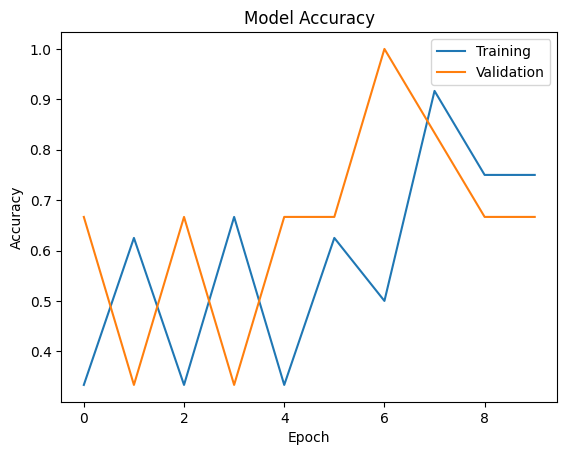

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.show()

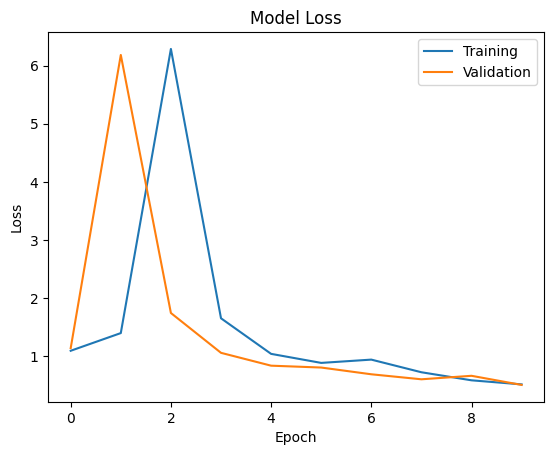

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step - accuracy: 0.8333 - loss: 0.4884
Validation Loss: 0.4883674681186676
Validation Accuracy: 0.8333333134651184


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Imges.zip to Imges (1).zip


In [61]:
from tensorflow.keras.preprocessing import image
import numpy as np
img = image.load_img("/content/Imges/Sonu/2.jpeg", target_size=(224, 224))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)
prediction = model.predict(img)
class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100
print("Predicted Person:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Person: Sonu
Confidence: 56.88 %


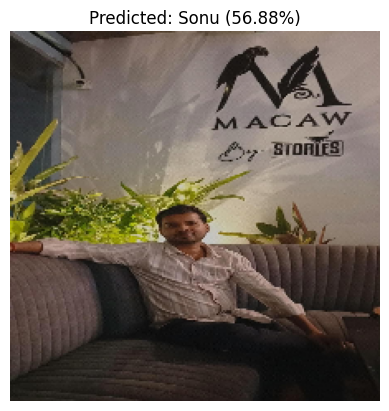

In [62]:
import matplotlib.pyplot as plt
plt.imshow(img[0])
plt.axis('off')
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
plt.show()